# Hands-on Neural SDE: Learning Short-Rate Dynamics from Path Increments

This notebook accompanies **Chapter 9 (AI and Machine Learning for Mortgage Modeling)**.

Chapter 4 wrote down the classical Vasicek short-rate process as a rigid parametric Stochastic Differential Equation (SDE):

$$dr_t = a(\theta - r_t) dt + \sigma dW_t, \quad a = 0.5, \quad \theta = 4.5\%, \quad \sigma = 0.6\%$$

A **Neural SDE** keeps the stochastic diffusion driving term $\sigma dW_t$ and replaces the handcrafted drift with a deep neural network $\mu_\theta(r_t, t)$:

$$dr_t = \mu_\theta(r_t, t) dt + \sigma dW_t$$

In this hands-on lab, we:
1. Simulate ground-truth Vasicek interest rate paths using the Euler-Maruyama method;
2. Train a PyTorch neural network to recover the unknown drift from realized discrete path increments;
3. Evaluate in-sample accuracy and extract the implied mean-reversion level $\hat{\theta}$;
4. Stress-test out-of-sample extrapolation to rates never seen in historical paths ($r > 10\%$);
5. Experiment with architectural inductive bias: **Tanh** (smooth saturation) vs. **ReLU** (piecewise-linear extrapolation).

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# Cap thread pool to 4 threads to prevent OpenMP barrier contention on small tensors
torch.set_num_threads(4)

# Fix seeds for exact reproducibility
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
})
print(f"PyTorch version: {torch.__version__} | Active CPU threads: {torch.get_num_threads()}")

PyTorch version: 2.10.0+cu128 | Active CPU threads: 4


## 1. Simulating Ground-Truth Short-Rate Paths

Under the Euler-Maruyama discretization with monthly step size $\Delta t = 1/12$:

$$r_{t+\Delta t} = r_t + a(\theta - r_t) \Delta t + \sigma \sqrt{\Delta t} \, Z_t, \quad Z_t \sim \mathcal{N}(0, 1)$$

We simulate 200 interest-rate paths over a 5-year horizon (60 monthly steps), starting at $r_0 = \theta = 4.5\%$.

Simulated 200 paths over 60 months (12,000 total transition pairs).
Training rates span: 2.61% to 6.65% (Range width: 4.04%)


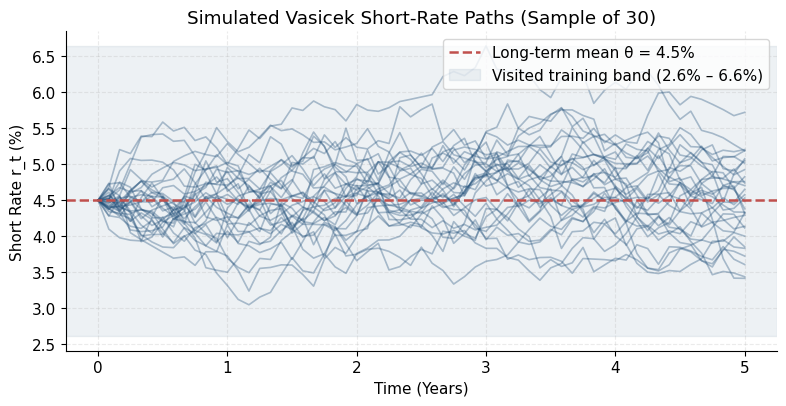

In [2]:
A_TRUE = 0.5
THETA_TRUE = 0.045
SIGMA = 0.006
DT = 1.0 / 12.0
N_PATHS = 200
N_STEPS = 60
R0 = THETA_TRUE

def true_drift(r):
    """Analytical Vasicek drift for verification."""
    return A_TRUE * (THETA_TRUE - r)

def simulate_paths(n_paths=N_PATHS, n_steps=N_STEPS, seed=SEED):
    rng = np.random.default_rng(seed)
    r = np.full(n_paths, R0)
    here, nxt = [], []
    path_history = [r.copy()]
    for _ in range(n_steps):
        dw = rng.normal(0.0, math.sqrt(DT), n_paths)
        r_new = r + true_drift(r) * DT + SIGMA * dw
        here.append(r.copy())
        nxt.append(r_new.copy())
        r = r_new
        path_history.append(r.copy())
    return np.concatenate(here), np.concatenate(nxt), np.array(path_history)

r_here, r_next, all_paths = simulate_paths()
lo, hi = r_here.min(), r_here.max()

print(f"Simulated {N_PATHS} paths over {N_STEPS} months ({len(r_here):,} total transition pairs).")
print(f"Training rates span: {lo*100:.2f}% to {hi*100:.2f}% (Range width: {(hi-lo)*100:.2f}%)")

# Plot a sample of paths
fig, ax = plt.subplots(figsize=(8, 4.2))
time_axis = np.arange(N_STEPS + 1) * DT
ax.plot(time_axis, all_paths[:, :30] * 100, color="#1f4e79", alpha=0.35, lw=1.2)
ax.axhline(THETA_TRUE * 100, color="#c0504d", ls="--", lw=1.8, label=f"Long-term mean θ = {THETA_TRUE*100:.1f}%")
ax.axhspan(lo * 100, hi * 100, color="#1f4e79", alpha=0.08, label=f"Visited training band ({lo*100:.1f}% – {hi*100:.1f}%)")
ax.set_xlabel("Time (Years)")
ax.set_ylabel("Short Rate r_t (%)")
ax.set_title("Simulated Vasicek Short-Rate Paths (Sample of 30)")
ax.legend(frameon=True, loc="upper right")
plt.tight_layout()
plt.show()

## 2. The Neural SDE Drift Estimator

Because Brownian motion has zero mean ($\mathbb{E}[\Delta W_t \mid r_t] = 0$), taking conditional expectations of the Euler-Maruyama increment yields:

$$\mathbb{E}[r_{t+\Delta t} - r_t \mid r_t] = \mu(r_t) \Delta t$$

The stochastic noise averages away when aggregating across thousands of path increments. Regressing realized changes $\Delta r_i = r_{t+\Delta t} - r_t$ onto current levels $r_t$ recovers the drift function!

We construct a multi-layer perceptron `DriftNet` with two hidden layers (width 32) and $\tanh$ activations.

In [3]:
class DriftNet(nn.Module):
    """Neural drift network with smooth Tanh activations."""
    def __init__(self, width=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1),
        )

    def forward(self, r):
        return self.net(r.unsqueeze(-1)).squeeze(-1)

model_tanh = DriftNet()
num_params = sum(p.numel() for p in model_tanh.parameters())
print("DriftNet Architecture:")
print(model_tanh)
print(f"Total trainable parameters: {num_params}")

DriftNet Architecture:
DriftNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Total trainable parameters: 1153


## 3. Training Loop with Adam Optimizer

We minimize the Mean Squared Error:

$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^N \left(\mu_\theta(r_{i,t}) \Delta t - \Delta r_i\right)^2$$

Fitting Neural SDE DriftNet (2,000 epochs)...


Initial loss: 3.993e-06 | Final loss: 2.995e-06


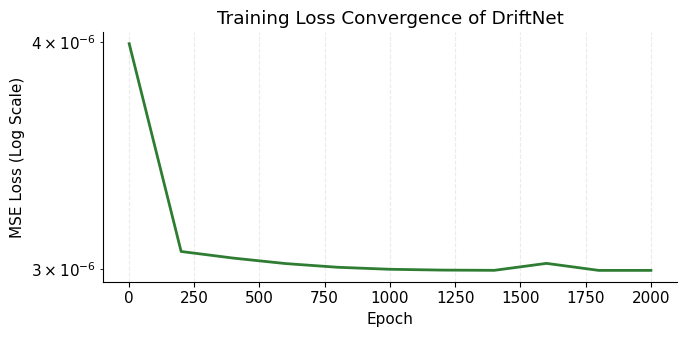

In [4]:
def train_model(model, r_here, r_next, epochs=2000, lr=1e-3, seed=SEED):
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    r = torch.tensor(r_here, dtype=torch.float32)
    dr = torch.tensor(r_next - r_here, dtype=torch.float32)
    losses = []
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        pred_dr = model(r) * DT
        loss = F.mse_loss(pred_dr, dr)
        loss.backward()
        optimizer.step()
        if epoch % 200 == 0 or epoch == 1:
            losses.append((epoch, float(loss.detach())))
    return model, losses

print("Fitting Neural SDE DriftNet (2,000 epochs)...")
model_tanh, loss_history = train_model(model_tanh, r_here, r_next, epochs=2000)
epochs_idx, loss_vals = zip(*loss_history)
print(f"Initial loss: {loss_vals[0]:.3e} | Final loss: {loss_vals[-1]:.3e}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epochs_idx, loss_vals, color="#2e7d32", lw=2)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (Log Scale)")
ax.set_title("Training Loss Convergence of DriftNet")
plt.tight_layout()
plt.show()

## 4. In-Sample Precision vs. Out-of-Sample Extrapolation

We evaluate the absolute drift error across two domains:
1. **In-sample domain**: $r \in [2.61\%, 6.65\%]$, the range spanned by training paths;
2. **Out-of-sample domain**: $r \in [0.0\%, 12.0\%]$, stretching into extreme high-rate regimes.

We also find the implied long-term mean $\hat{\theta}$ where the learned drift crosses zero ($\mu_\theta(\hat{\theta}) = 0$).

--- Empirical Verification Results ---
Mean |drift error| inside training band:  3.95 bp/yr
Max  |drift error| inside training band:  8.80 bp/yr
Implied reversion mean θ_hat:           4.52% (True θ: 4.50%)
Max  |drift error| at r = 12%:           27.13 bp/yr (True: -375 bp/yr)


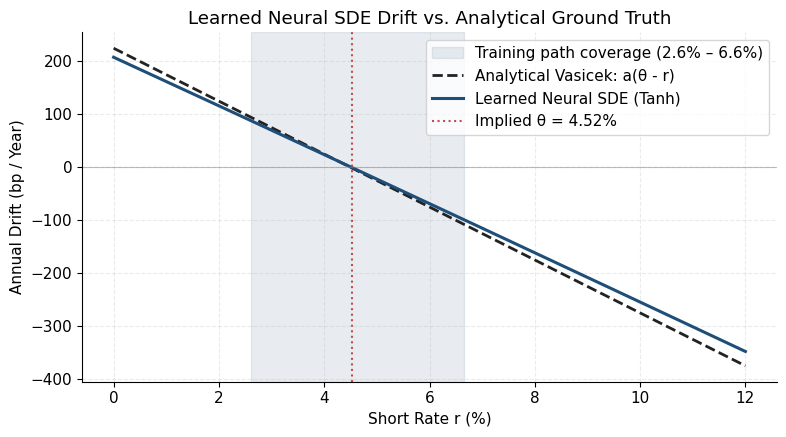

In [5]:
def evaluate_drift(model, grid):
    with torch.no_grad():
        pred = model(torch.tensor(grid, dtype=torch.float32)).numpy()
    err_bp = np.abs(pred - true_drift(grid)) * 1e4
    return pred, err_bp

inside_grid = np.linspace(lo, hi, 200)
outside_grid = np.linspace(0.0, 0.12, 500)

pred_inside, err_inside = evaluate_drift(model_tanh, inside_grid)
pred_outside, err_outside = evaluate_drift(model_tanh, outside_grid)

# Find implied mean reversion level
fine_grid = np.linspace(lo, hi, 5000)
pred_fine, _ = evaluate_drift(model_tanh, fine_grid)
theta_hat = fine_grid[np.argmin(np.abs(pred_fine))]

print("--- Empirical Verification Results ---")
print(f"Mean |drift error| inside training band:  {err_inside.mean():.2f} bp/yr")
print(f"Max  |drift error| inside training band:  {err_inside.max():.2f} bp/yr")
print(f"Implied reversion mean θ_hat:           {theta_hat*100:.2f}% (True θ: {THETA_TRUE*100:.2f}%)")
print(f"Max  |drift error| at r = 12%:           {err_outside[-1]:.2f} bp/yr (True: {true_drift(0.12)*1e4:.0f} bp/yr)")

# Replication plot
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axvspan(lo * 100, hi * 100, color="#1f4e79", alpha=0.1, label=f"Training path coverage ({lo*100:.1f}% – {hi*100:.1f}%)")
ax.plot(outside_grid * 100, true_drift(outside_grid) * 1e4, color="#222222", ls="--", lw=2, label="Analytical Vasicek: a(θ - r)")
ax.plot(outside_grid * 100, pred_outside * 1e4, color="#1f4e79", lw=2.2, label="Learned Neural SDE (Tanh)")
ax.axhline(0, color="grey", lw=0.8, alpha=0.5)
ax.axvline(theta_hat * 100, color="#c0504d", ls=":", lw=1.5, label=f"Implied θ = {theta_hat*100:.2f}%")

ax.set_xlabel("Short Rate r (%)")
ax.set_ylabel("Annual Drift (bp / Year)")
ax.set_title("Learned Neural SDE Drift vs. Analytical Ground Truth")
ax.legend(frameon=True, loc="upper right")
plt.tight_layout()
plt.show()

## 5. Architectural Experiment: Tanh vs. ReLU Inductive Bias

How does activation choice alter out-of-sample behavior?
- **Tanh**: S-shaped and bounded in $(-1, 1)$, causing the outer drift to flatten out asymptotically.
- **ReLU**: Piecewise linear ($\max(0, z)$), causing extrapolation beyond the final knot to project linear rays with whatever slope the final boundary weights possessed.

Fitting DriftNet with ReLU activations...


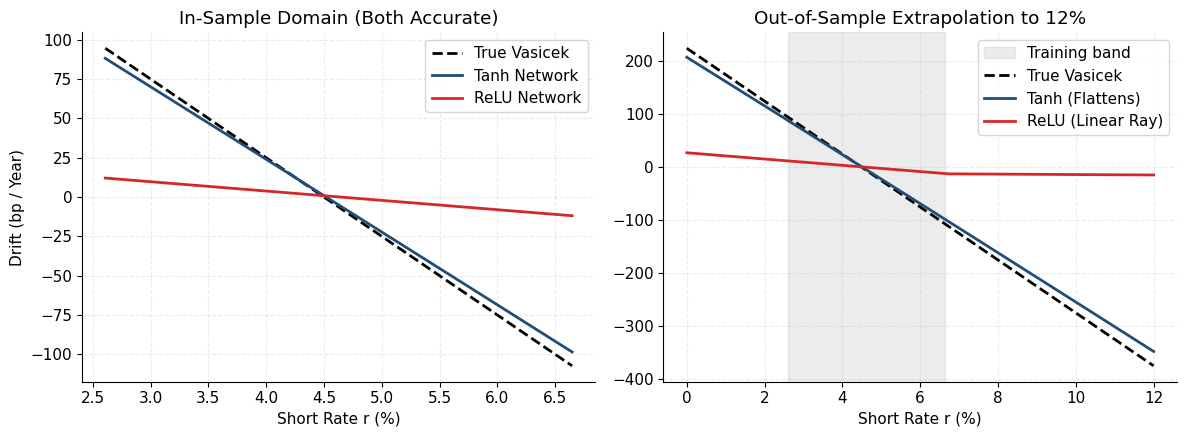

In [6]:
class DriftNetReLU(nn.Module):
    def __init__(self, width=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width),
            nn.ReLU(),
            nn.Linear(width, width),
            nn.ReLU(),
            nn.Linear(width, 1),
        )

    def forward(self, r):
        return self.net(r.unsqueeze(-1)).squeeze(-1)

print("Fitting DriftNet with ReLU activations...")
model_relu = DriftNetReLU()
model_relu, _ = train_model(model_relu, r_here, r_next, epochs=2000)

pred_relu_outside, _ = evaluate_drift(model_relu, outside_grid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# In-sample comparison
ax1.plot(inside_grid * 100, true_drift(inside_grid) * 1e4, "k--", lw=2, label="True Vasicek")
ax1.plot(inside_grid * 100, pred_inside * 1e4, color="#1f4e79", lw=2, label="Tanh Network")
ax1.plot(inside_grid * 100, evaluate_drift(model_relu, inside_grid)[0] * 1e4, color="#d62728", lw=2, label="ReLU Network")
ax1.set_title("In-Sample Domain (Both Accurate)")
ax1.set_xlabel("Short Rate r (%)")
ax1.set_ylabel("Drift (bp / Year)")
ax1.legend(frameon=True)

# Out-of-sample extrapolation
ax2.axvspan(lo * 100, hi * 100, color="gray", alpha=0.15, label="Training band")
ax2.plot(outside_grid * 100, true_drift(outside_grid) * 1e4, "k--", lw=2, label="True Vasicek")
ax2.plot(outside_grid * 100, pred_outside * 1e4, color="#1f4e79", lw=2, label="Tanh (Flattens)")
ax2.plot(outside_grid * 100, pred_relu_outside * 1e4, color="#d62728", lw=2, label="ReLU (Linear Ray)")
ax2.set_title("Out-of-Sample Extrapolation to 12%")
ax2.set_xlabel("Short Rate r (%)")
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()

## 6. Trading Desk Lessons & Model Governance

1. **Non-parametric Drift Recovery**: The Neural SDE accurately identified the unobserved mean-reversion rate $\hat{\theta} = 4.52\%$ (true: $4.50\%$) and achieved a mean error of under $4$ bp/yr inside the visited rate regime without being handed any parametric functional form.
2. **The Illusion of Out-of-Sample Extrapolation**: The training objective only minimizes error on transitions that actually occurred in the sample. Outside the visited band $[2.61\%, 6.65\%]$, the network's prediction is governed purely by its architectural inductive bias rather than any economic law.
3. **Desk Rule**: In a changing macro environment (such as the 2022 Fed rate hike from $0.1\%$ to $4.4\%$), models fitted on past calm regimes are forced into pure extrapolation. Desks must either enforce explicit economic asymptotic priors or anchor the Neural SDE to a structural baseline pricer!